       MUSIC MOOD PREDICTION PROJECT

CSV file loaded successfully!

========== AVAILABLE COLUMNS ==========
['song', 'tempo', 'energy', 'danceability', 'valence', 'acousticness', 'mood']

========== FIRST 5 ROWS ==========
     song   tempo  energy  danceability  valence  acousticness     mood
0  Song 1  109.60   0.855         0.874    0.586         0.024    Happy
1  Song 2  126.28   0.848         0.618    0.118         0.226    Angry
2  Song 3   72.66   0.413         0.397    0.147         0.764      Sad
3  Song 4   58.41   0.338         0.295    0.528         0.798  Relaxed
4  Song 5  118.45   0.737         0.745    0.884         0.224    Happy

========== DATASET INFORMATION ==========
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   song          500 non-null    str    
 1   tempo         500 non-null    float64
 2   energy        500 non-null    f

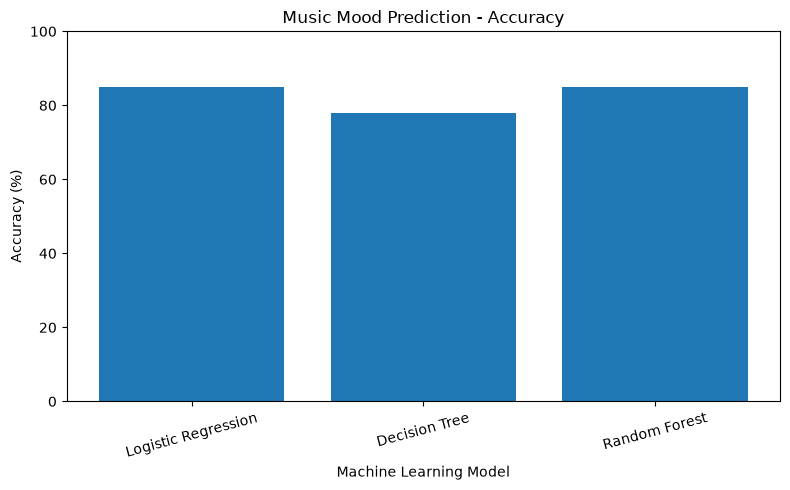

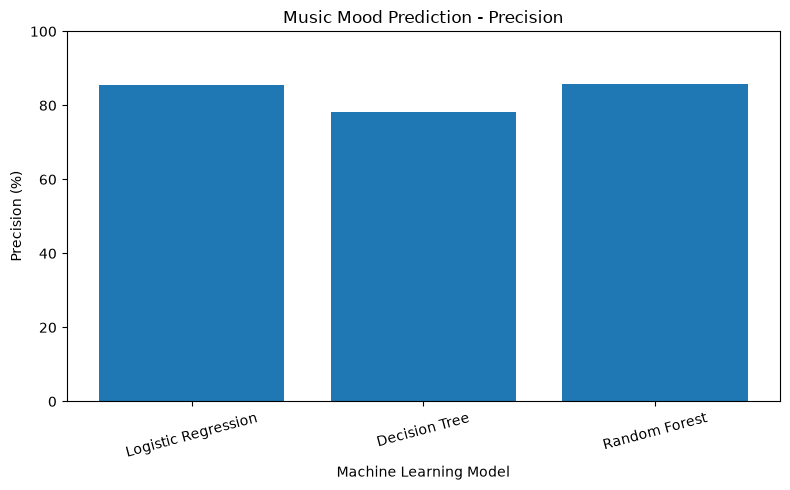

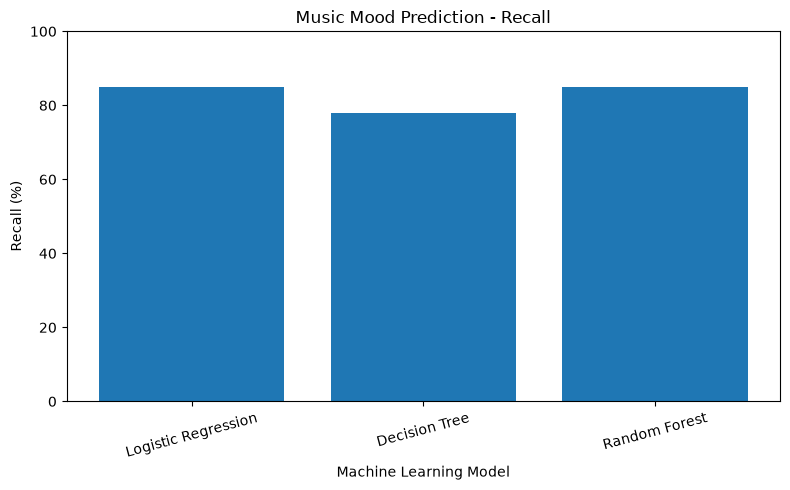

        RANDOM FOREST CONFUSION MATRIX
[[19  0  0  0  0  0]
 [ 0 12  0  0  1  3]
 [ 0  0 12  4  0  0]
 [ 0  0  2 13  0  0]
 [ 0  3  0  0 10  2]
 [ 0  0  0  0  0 19]]


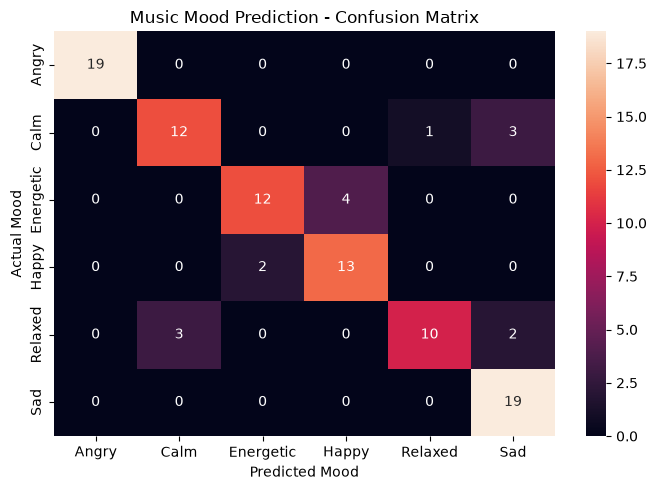

        CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00        19
        Calm       0.80      0.75      0.77        16
   Energetic       0.86      0.75      0.80        16
       Happy       0.76      0.87      0.81        15
     Relaxed       0.91      0.67      0.77        15
         Sad       0.79      1.00      0.88        19

    accuracy                           0.85       100
   macro avg       0.85      0.84      0.84       100
weighted avg       0.86      0.85      0.85       100

          NEW SONG PREDICTION

New Song Features:
   tempo  energy  danceability  valence  acousticness
0    125    0.85           0.8      0.9          0.15

Predicted Music Mood:
🎵 Happy
           PROJECT COMPLETED

Data Collection       ✓
Data Preprocessing    ✓
Machine Learning      ✓
Logistic Regression   ✓
Decision Tree         ✓
Random Forest         ✓
Accuracy              ✓
Precision             ✓
Recall          

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

file_path = r"C:\Users\kavya\Desktop\song_ml_dataset_500.csv"

# Read CSV file
df = pd.read_csv(file_path)

print("       MUSIC MOOD PREDICTION PROJECT")

print("\nCSV file loaded successfully!")


# 3. CLEAN COLUMN NAMES

# Remove spaces and convert column names to lowercase
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\n========== AVAILABLE COLUMNS ==========")
print(df.columns.tolist())


# 4. DISPLAY DATA

print("\n========== FIRST 5 ROWS ==========")
print(df.head())


print("\n========== DATASET INFORMATION ==========")
df.info()


print("\n========== DATASET SIZE ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


# 5. FIND MOOD/TARGET COLUMN

# Possible names for the target column
possible_target_columns = [
    "mood",
    "label",
    "emotion",
    "target",
    "category"
]

target_column = None

for column in possible_target_columns:

    if column in df.columns:
        target_column = column
        break


# If target column was not found
if target_column is None:

    print("\nERROR: Could not find the mood/target column.")

    print("\nAvailable columns:")
    print(df.columns.tolist())

    raise ValueError(
        "Please check your CSV file and make sure it contains "
        "a target column such as 'mood' or 'label'."
    )


print("\nTarget column found:", target_column)


# 6. MOOD COUNT

print("\n========== MOOD COUNT ==========")

print(
    df[target_column].value_counts()
)

# 7. REQUIRED FEATURES

features = [
    "tempo",
    "energy",
    "danceability",
    "valence",
    "acousticness"
]

# 8. CHECK FEATURES

missing_features = [
    feature
    for feature in features
    if feature not in df.columns
]


if len(missing_features) > 0:

    print("\nERROR: Missing feature columns:")

    for feature in missing_features:
        print("-", feature)

    print("\nAvailable columns:")
    print(df.columns.tolist())

    raise ValueError(
        "Some required feature columns are missing from the CSV."
    )


# 9. DATA PREPROCESSING
print("          DATA PREPROCESSING")

# Check missing values
print("\nMissing values BEFORE cleaning:")

print(
    df.isnull().sum()
)

# Remove duplicate rows

duplicate_count = df.duplicated().sum()

print(
    "\nDuplicate rows found:",
    duplicate_count
)


df = df.drop_duplicates()

# Convert numerical columns to numeric

for column in features:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Remove missing values

df = df.dropna(
    subset=features + [target_column]
)

# Remove empty target values
df = df[
    df[target_column].astype(str).str.strip() != ""
]

print("\nMissing values AFTER cleaning:")

print(
    df.isnull().sum()
)

print("\nDataset after preprocessing:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


# 10. SELECT FEATURES AND TARGET

X = df[features]
y = df[target_column]

print("        FEATURES AND TARGET")

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


print("\nTarget classes:")
print(
    sorted(y.astype(str).unique())
)

# 11. TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("             TRAIN / TEST DATA")

print(
    "Training records :",
    len(X_train)
)
print(
    "Testing records  :",
    len(X_test)
)
# 12. CREATE MACHINE LEARNING MODELS
models = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]),
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

# 13. TRAIN MODELS

results = {}
predictions = {}

print("        MODEL PERFORMANCE")


for name, model in models.items():

    print("\n------------------------------------------")

    print(
        "Training:",
        name
    )

    print("------------------------------------------")

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Predict test data
    y_pred = model.predict(
        X_test
    )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    }

    predictions[name] = y_pred

    # Display results
    print(
        "Accuracy :",
        round(accuracy * 100, 2),
        "%"
    )
    print(
        "Precision:",
        round(precision * 100, 2),
        "%"
    )
    print(
        "Recall   :",
        round(recall * 100, 2),
        "%"
    )

# 14. RESULT TABLE

result_df = pd.DataFrame(
    results
).T

print("             FINAL RESULTS")
print(
    (result_df * 100).round(2)
)

# 15. ACCURACY GRAPH

plt.figure(
    figsize=(8, 5)
)
plt.bar(
    result_df.index,
    result_df["Accuracy"] * 100
)
plt.xlabel(
    "Machine Learning Model"
)
plt.ylabel(
    "Accuracy (%)"
)
plt.title(
    "Music Mood Prediction - Accuracy"
)
plt.ylim(
    0,
    100
)
plt.xticks(
    rotation=15
)
plt.tight_layout()
plt.show()

# 16. PRECISION GRAPH

plt.figure(
    figsize=(8, 5)
)
plt.bar(
    result_df.index,
    result_df["Precision"] * 100
)
plt.xlabel(
    "Machine Learning Model"
)
plt.ylabel(
    "Precision (%)"
)
plt.title(
    "Music Mood Prediction - Precision"
)
plt.ylim(
    0,
    100
)
plt.xticks(
    rotation=15
)
plt.tight_layout()
plt.show()

# 17. RECALL GRAPH

plt.figure(
    figsize=(8, 5)
)
plt.bar(
    result_df.index,
    result_df["Recall"] * 100
)
plt.xlabel(
    "Machine Learning Model"
)
plt.ylabel(
    "Recall (%)"
)
plt.title(
    "Music Mood Prediction - Recall"
)
plt.ylim(
    0,
    100
)
plt.xticks(
    rotation=15
)
plt.tight_layout()
plt.show()

# 18. RANDOM FOREST CONFUSION MATRIX

y_pred_rf = predictions[
    "Random Forest"
]

# Automatically get classes from dataset
labels = sorted(
    y_test.astype(str).unique()
)

cm = confusion_matrix(

    y_test.astype(str),

    y_pred_rf.astype(str),

    labels=labels
)

print("        RANDOM FOREST CONFUSION MATRIX")

print(cm)

plt.figure(
    figsize=(7, 5)
)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel(
    "Predicted Mood"
)
plt.ylabel(
    "Actual Mood"
)
plt.title(
    "Music Mood Prediction - Confusion Matrix"
)
plt.tight_layout()
plt.show()

# 19. CLASSIFICATION REPORT

print("        CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

# 20. PREDICT A NEW SONG
print("          NEW SONG PREDICTION")

# Example song
new_song = pd.DataFrame(
    [
        [
            125,    # Tempo
            0.85,   # Energy
            0.80,   # Danceability
            0.90,   # Valence
            0.15    # Acousticness
        ]
    ],
    columns=features
)


print("\nNew Song Features:")

print(
    new_song
)

# Use Random Forest

random_forest_model = models[
    "Random Forest"
]

prediction = random_forest_model.predict(
    new_song
)

print("\nPredicted Music Mood:")

print(
    "🎵",
    prediction[0]
)

# 21. FINAL MESSAGE
print("           PROJECT COMPLETED")

print("""
Data Collection       ✓
Data Preprocessing    ✓
Machine Learning      ✓
Logistic Regression   ✓
Decision Tree         ✓
Random Forest         ✓
Accuracy              ✓
Precision             ✓
Recall                ✓
Confusion Matrix      ✓
Classification Report ✓
New Song Prediction   ✓
""")